In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

# 1. Ambil data hasil pre-processing Anda
folder_sumber = r"C:\Users\Balqoz\skripsiku\Hasil ExG"
files = glob.glob(os.path.join(folder_sumber, "Hasil_ExG_*.xlsx"))
df_all = pd.concat([pd.read_excel(f) for f in files], ignore_index=True)

In [2]:
# 2. Feature Engineering: Tambahkan Fitur IR dan Rasio IR terhadap RGB
df_all['IR_to_R'] = df_all['IR_Intensity (%)'] / (df_all['R'] + 1)
df_all['IR_to_G'] = df_all['IR_Intensity (%)'] / (df_all['G'] + 1)
df_all['IR_to_B'] = df_all['IR_Intensity (%)'] / (df_all['B'] + 1)

# Definisikan Fitur X (sekarang menyertakan IR) dan Target y
X = df_all[["r", "g", "b", "Excess_Green", "IR_Intensity (%)", "IR_to_R", "IR_to_G", "IR_to_B"]]
y = df_all["Chl_Total"]

In [3]:
# 3. Evaluasi Menggunakan LOOCV (Leave-One-Out Cross Validation) dengan Dekomposisi Arnon
loo = LeaveOneOut()

# List penampung nilai Total Klorofil (Target Utama Model)
y_true_total, y_pred_total = [], []

# List penampung komponen pecahan Arnon untuk visualisasi & evaluasi sub-pigmen
y_true_a, y_pred_a = [], []
y_true_b, y_pred_b = [], []

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Sederhanakan parameter RF agar tidak overfitting pada 16 data
    rf_model = RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42)
    rf_model.fit(X_train, y_train)
    
    # Prediksi nilai total klorofil
    pred_total = rf_model.predict(X_test)[0]
    actual_total = y_test.values[0]
    
    # Simpan hasil prediksi & aktual Total Klorofil
    y_true_total.append(actual_total)
    y_pred_total.append(pred_total)
    
    # Dekomposisi pecahan Arnon (37% Klorofil a dan 63% Klorofil b)
    y_true_a.append(actual_total * 0.37)
    y_pred_a.append(pred_total * 0.37)
    
    y_true_b.append(actual_total * 0.63)
    y_pred_b.append(pred_total * 0.63)

# Konversi seluruh list menjadi numpy array
y_true_total, y_pred_total = np.array(y_true_total), np.array(y_pred_total)
y_true_a, y_pred_a = np.array(y_true_a), np.array(y_pred_a)
y_true_b, y_pred_b = np.array(y_true_b), np.array(y_pred_b)

In [4]:
# 4. Hitung Metrik Evaluasi Komprehensif untuk Sidang Skripsi
def hitung_metrik(y_true, y_pred, nama_komponen):
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    
    print(f"-------- EVALUASI {nama_komponen.upper()} (RF + IR) --------")
    print(f"R² Score : {r2:.4f}")
    print(f"MAPE     : {mape:.2f}%")
    print(f"MAE      : {mae:.4f}")
    print(f"MSE      : {mse:.4f}\n")

print("=====================================================")
print("     HASIL EVALUASI RANDOM FOREST MULTISENSOR        ")
print("=====================================================")
hitung_metrik(y_true_total, y_pred_total, "Total Klorofil")
hitung_metrik(y_true_a, y_pred_a, "Klorofil a")
hitung_metrik(y_true_b, y_pred_b, "Klorofil b")

     HASIL EVALUASI RANDOM FOREST MULTISENSOR        
-------- EVALUASI TOTAL KLOROFIL (RF + IR) --------
R² Score : 0.7549
MAPE     : 3.91%
MAE      : 0.8123
MSE      : 1.5350

-------- EVALUASI KLOROFIL A (RF + IR) --------
R² Score : 0.7549
MAPE     : 3.91%
MAE      : 0.3005
MSE      : 0.2101

-------- EVALUASI KLOROFIL B (RF + IR) --------
R² Score : 0.7549
MAPE     : 3.91%
MAE      : 0.5117
MSE      : 0.6092



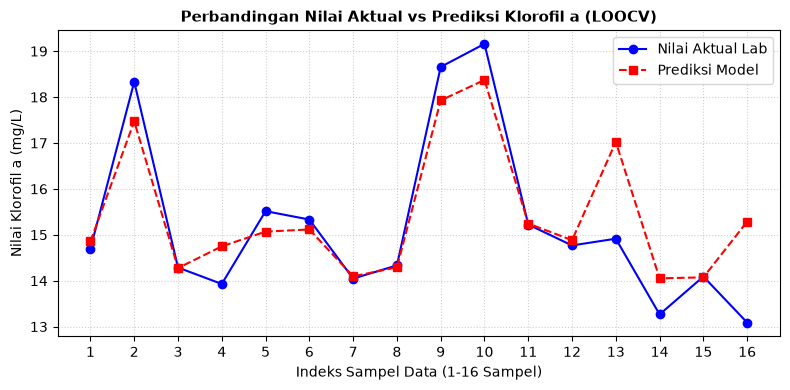

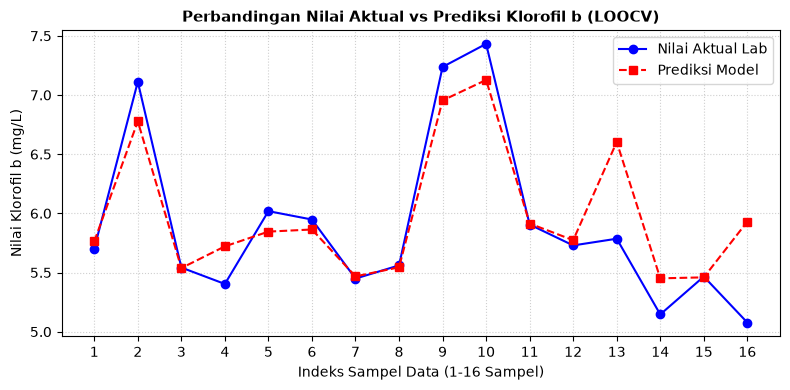

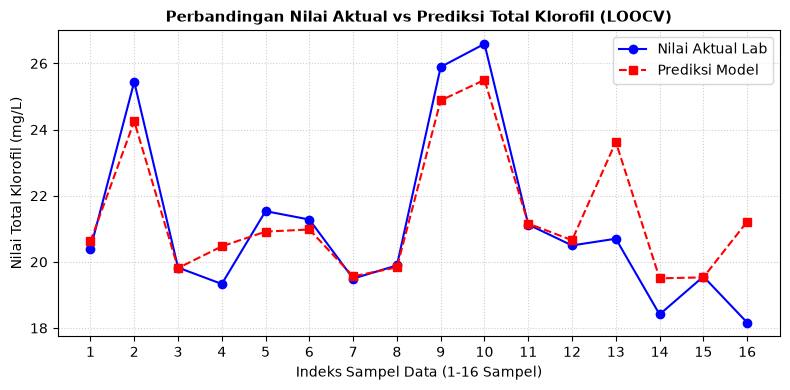

In [14]:
y_actual_total = np.array(y_true_total)
y_pred_total = np.array(y_pred_total)

y_actual_a = y_actual_total * 0.7205
y_pred_a = y_pred_total * 0.7205

y_actual_b = y_actual_total * 0.2795
y_pred_b = y_pred_total * 0.2795

# Membuat sumbu X berdasarkan indeks/jumlah sampel (1-16 sampel)
sample_index = np.arange(1, len(y_actual_total) + 1)

# ==========================================
# 1. GRAFIK PERBANDINGAN KLOROFIL A
# ==========================================
plt.figure(figsize=(8, 4))
plt.plot(sample_index, y_actual_a, marker='o', color='blue', linewidth=1.5, label='Nilai Aktual Lab')
plt.plot(sample_index, y_pred_a, marker='s', linestyle='--', color='red', linewidth=1.5, label='Prediksi Model')

plt.title('Perbandingan Nilai Aktual vs Prediksi Klorofil a (LOOCV)', fontsize=11, fontweight='bold')
plt.xlabel('Indeks Sampel Data (1-16 Sampel)', fontsize=10)
plt.ylabel('Nilai Klorofil a (mg/L)', fontsize=10)
plt.xticks(sample_index)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# 2. GRAFIK PERBANDINGAN KLOROFIL B
# ==========================================
plt.figure(figsize=(8, 4))
plt.plot(sample_index, y_actual_b, marker='o', color='blue', linewidth=1.5, label='Nilai Aktual Lab')
plt.plot(sample_index, y_pred_b, marker='s', linestyle='--', color='red', linewidth=1.5, label='Prediksi Model')

plt.title('Perbandingan Nilai Aktual vs Prediksi Klorofil b (LOOCV)', fontsize=11, fontweight='bold')
plt.xlabel('Indeks Sampel Data (1-16 Sampel)', fontsize=10)
plt.ylabel('Nilai Klorofil b (mg/L)', fontsize=10)
plt.xticks(sample_index)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# 3. GRAFIK PERBANDINGAN TOTAL KLOROFIL
# ==========================================
plt.figure(figsize=(8, 4))
plt.plot(sample_index, y_actual_total, marker='o', color='blue', linewidth=1.5, label='Nilai Aktual Lab')
plt.plot(sample_index, y_pred_total, marker='s', linestyle='--', color='red', linewidth=1.5, label='Prediksi Model')

plt.title('Perbandingan Nilai Aktual vs Prediksi Total Klorofil (LOOCV)', fontsize=11, fontweight='bold')
plt.xlabel('Indeks Sampel Data (1-16 Sampel)', fontsize=10)
plt.ylabel('Nilai Total Klorofil (mg/L)', fontsize=10)
plt.xticks(sample_index)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Latih ulang model pada SELURUH data (16 baris) agar pengetahuannya maksimal sebelum masuk web
model_final = RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42)
model_final.fit(X, y)

# Simpan model final ke dalam file .pkl
joblib.dump(model_final, 'model_rf.pkl')
print("Model berhasil disimpan dengan nama 'model_rf.pkl'!")

Model berhasil disimpan dengan nama 'model_rf.pkl'!
